## 2. Data Understanding

The curated dataset is a single quarterly table (`data/curated/quarterly_macro_features.csv`)
built from ABS CPI, ABS trimmed-mean CPI, RBA cash-rate decisions, RBA/ABS labour-force and
producer-price series, WTI/Brent crude, and the RBA's own published CPI forecast workbook —
joined on quarter, no manual pasting.

In [37]:
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, Image, display

INK, PAPER, ACCENT, ACCENT_SOFT, HIGHLIGHT, GRID = (
    "#16211c", "#f7f8f5", "#1f6f66", "#bfe3dd", "#a8691f", "#d9ddd6",
)
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "axes.edgecolor": GRID,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 11, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
})

CURATED = PROJECT_ROOT / "data/curated/quarterly_macro_features.csv"
df = pd.read_csv(CURATED)
print(f"{len(df)} quarters, {df['quarter'].iloc[0]}–{df['quarter'].iloc[-1]}, {df.shape[1]} columns")
df[["quarter", "cpi_yoy", "trimmed_mean_cpi_yoy", "unemployment_rate", "cash_rate"]].tail()

128 quarters, 1995Q1–2026Q4, 54 columns


,quarter,cpi_yoy,trimmed_mean_cpi_yoy,unemployment_rate,cash_rate
123,2025Q4,3.7,3.3,4.257327,3.600000
124,2026Q1,4.0,3.5,4.223809,3.850000
125,2026Q2,3.9,3.6,4.434078,4.266667
126,2026Q3,NaN,NaN,4.461825,4.350000
127,2026Q4,NaN,NaN,NaN,NaN


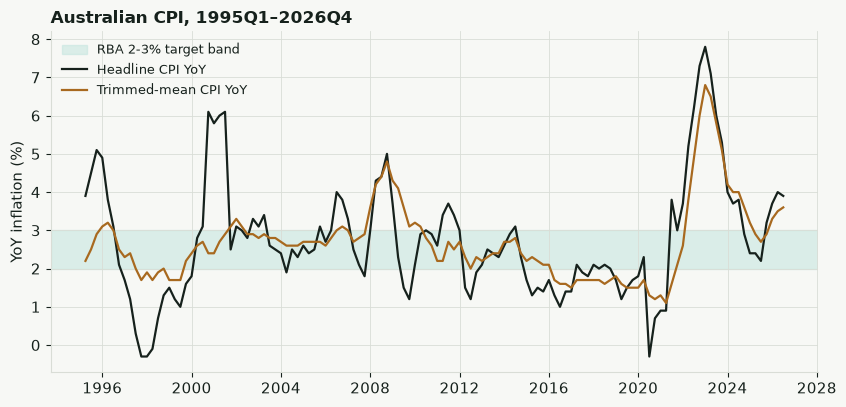

In [38]:
hist = df[["quarter", "cpi_yoy", "trimmed_mean_cpi_yoy"]].copy()
hist["quarter_date"] = pd.PeriodIndex(hist["quarter"], freq="Q").to_timestamp(how="end")

fig, ax = plt.subplots(figsize=(8.6, 4.2))
ax.axhspan(2, 3, color=ACCENT_SOFT, alpha=0.5, zorder=0, label="RBA 2-3% target band")
ax.plot(hist["quarter_date"], hist["cpi_yoy"], color=INK, linewidth=1.6, label="Headline CPI YoY")
ax.plot(hist["quarter_date"], hist["trimmed_mean_cpi_yoy"], color=HIGHLIGHT, linewidth=1.6,
        label="Trimmed-mean CPI YoY")
ax.set_ylabel("YoY inflation (%)")
ax.set_title(f"Australian CPI, {hist['quarter'].iloc[0]}–{hist['quarter'].iloc[-1]}",
             loc="left", fontsize=12, fontweight="bold")
ax.legend(frameon=False, loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()

Both series track each other closely except where headline gets pulled around by volatile
items the trimmed mean discards by construction — the GST introduction (2000-01) and the
2020 COVID childcare/fuel shock are the two sharpest headline-only spikes above.